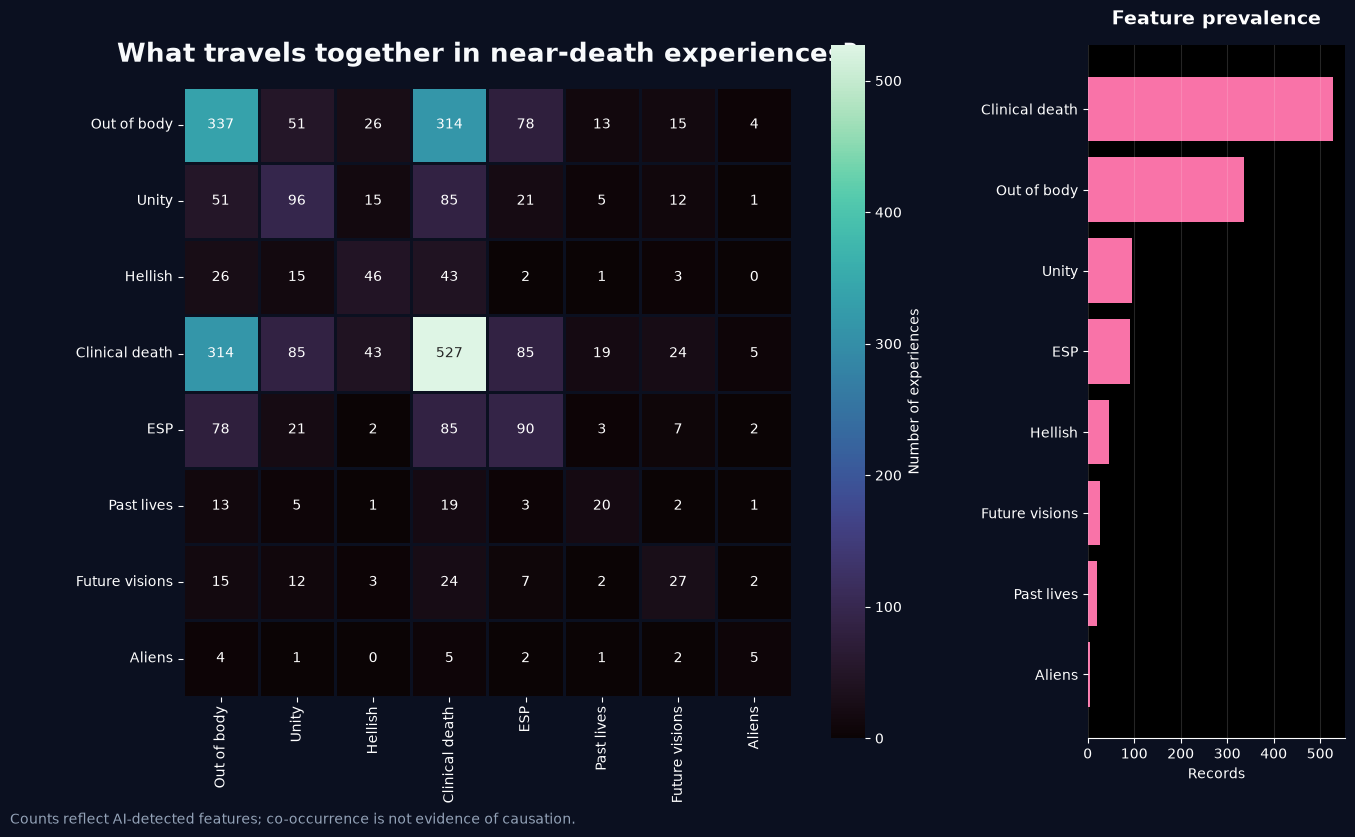

In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-07-21/nde_experiences.csv"
nde = pd.read_csv(url)

feature_cols = [
    "ai_obe", "ai_unity", "ai_hellish", "ai_clinical",
    "ai_esp", "ai_past_lives", "ai_world_future", "ai_aliens"
]

features = nde[feature_cols].fillna(False).astype(bool)
labels = {
    "ai_obe": "Out of body",
    "ai_unity": "Unity",
    "ai_hellish": "Hellish",
    "ai_clinical": "Clinical death",
    "ai_esp": "ESP",
    "ai_past_lives": "Past lives",
    "ai_world_future": "Future visions",
    "ai_aliens": "Aliens"
}

# Pairwise co-occurrence counts
cooccurrence = features.T.astype(int).dot(features.astype(int))
cooccurrence.index = [labels[x] for x in cooccurrence.index]
cooccurrence.columns = [labels[x] for x in cooccurrence.columns]

prevalence = features.sum().sort_values()
prevalence.index = [labels[x] for x in prevalence.index]

plt.style.use("dark_background")
fig = plt.figure(figsize=(15, 9), facecolor="#0b1020")
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.35], wspace=0.28)

ax_heat = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

sns.heatmap(
    cooccurrence,
    annot=True,
    fmt="g",
    cmap=sns.color_palette("mako", as_cmap=True),
    linewidths=0.8,
    linecolor="#0b1020",
    square=True,
    cbar_kws={"label": "Number of experiences"},
    ax=ax_heat
)

ax_heat.set_title(
    "What travels together in near-death experiences?",
    fontsize=19,
    fontweight="bold",
    color="#f8fafc",
    pad=18
)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")

ax_bar.barh(
    prevalence.index,
    prevalence.values,
    color="#f973a8",
    edgecolor="none"
)
ax_bar.set_title("Feature prevalence", fontsize=14, fontweight="bold", pad=15)
ax_bar.set_xlabel("Records")
ax_bar.grid(axis="x", alpha=0.15)
ax_bar.spines[["top", "right", "left"]].set_visible(False)

fig.text(
    0.01, 0.015,
    "Counts reflect AI-detected features; co-occurrence is not evidence of causation.",
    color="#94a3b8",
    fontsize=10
)

plt.show()